In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Define the parameters
k = 10        # Constant in the equation (e.g., spring constant)
h = 10       # Step size
x_start = 0    # Start of the interval
x_end = 10     # End of the interval
y_0 = 1.0      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx
# Create arrays to store x, y, and v values
x_values = np.arange(x_start, x_end + h, h)
y_values = np.zeros(len(x_values))
v_values = np.zeros(len(x_values))
# Set initial conditions
y_values[0] = y_0
v_values[0] = v_0

# Euler's Method loop
for i in range(1, len(x_values)):
    # Current values
    x_n = x_values[i - 1]
    y_n = y_values[i - 1]
    v_n = v_values[i - 1]    
    # Update equations
    y_values[i] = y_n + h * v_n
    v_values[i] = v_n + h * (-k * y_n)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, label='Position y(x)')
plt.plot(x_values, v_values, label='Velocity v(x)', linestyle='--')
plt.xlabel('x')
plt.ylabel('y and v')
plt.title('Solution of d²y/dx² = -ky using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x500 with 1 Axes>

  Stability Analysis   |   k = 10,  x in [0, 10]

Step size  h = 0.05
  Coefficient matrix A:
    [1.   0.05]
    [-0.5  1. ]
  Eigenvalues : [1.+0.15811388j 1.-0.15811388j]
  |lambda|    : [1.012423 1.012423]
  --> Solution may not be Entirely Stable ;)

Step size  h = 0.1
  Coefficient matrix A:
    [1.  0.1]
    [-1.  1.]
  Eigenvalues : [1.+0.31622777j 1.-0.31622777j]
  |lambda|    : [1.048809 1.048809]
  --> Solution may not be Entirely Stable ;)

Step size  h = 0.2
  Coefficient matrix A:
    [1.  0.2]
    [-2.  1.]
  Eigenvalues : [1.+0.63245553j 1.-0.63245553j]
  |lambda|    : [1.183216 1.183216]
  --> Solution may not be Entirely Stable ;)

Step size  h = 0.6
  Coefficient matrix A:
    [1.  0.6]
    [-6.  1.]
  Eigenvalues : [1.+1.8973666j 1.-1.8973666j]
  |lambda|    : [2.144761 2.144761]
  --> Solution may not be Entirely Stable ;)



Text(0.5, 1.01, "Euler's Method — Stability Analysis via Coefficient Matrix Eigenvalues\nd²y/dx² = −ky,   k = 10")

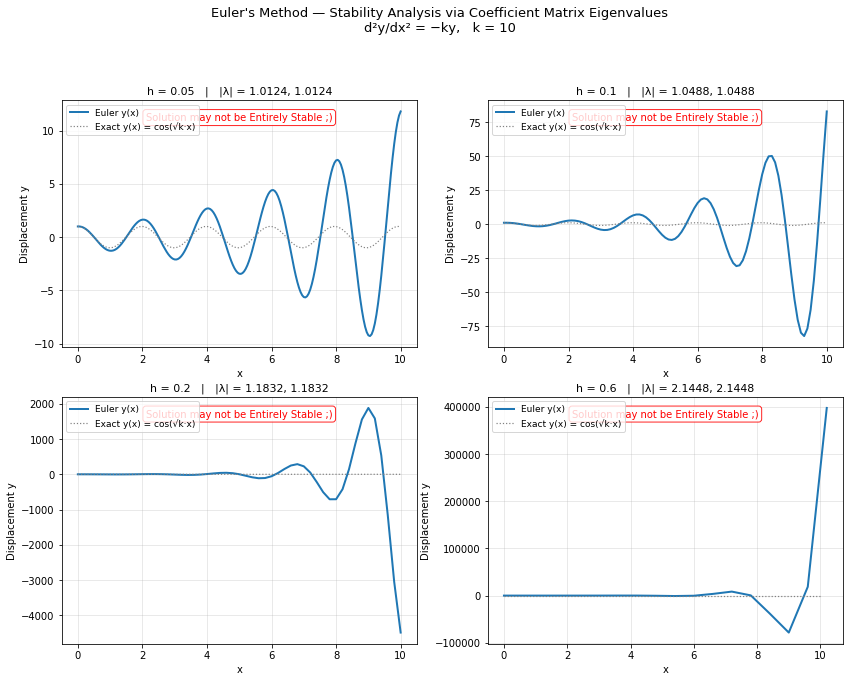

In [4]:
k = 10       
h = 10       
x_start = 0    
x_end = 10     
y_0 = 1.0      
v_0 = 0.0   

h_values = [0.05, 0.1, 0.2, 0.6]

def euler_method(h, k, x_start, x_end, y_0, v_0):
    A = np.array([[1,    h   ],
                  [-k*h, 1   ]])
 
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(x_values)):
        state = np.array([y_values[i-1], v_values[i-1]])
        new_state = A @ state
        y_values[i]  = new_state[0]
        v_values[i]  = new_state[1]
        
    return A, x_values, y_values

x_fine  = np.linspace(x_start, x_end, 500)
y_exact = np.cos(np.sqrt(k) * x_fine)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("=" * 56)
print(f"  Stability Analysis   |   k = {k},  x in [{x_start}, {x_end}]")
print("=" * 56)

for idx, h in enumerate(h_values):
 
    # 1. Build coefficient matrix & run simulation
    A, x_values, y_values = euler_method(h, k, x_start, x_end, y_0, v_0)
 
    # 2. Compute eigenvalues (using built-in np.linalg.eig, per vp9439-CH17)
    eigenvalues = np.linalg.eig(A)[0]
    magnitudes  = np.abs(eigenvalues)
    is_stable   = np.all(magnitudes < 1)
 
    # 3. Console output
    print(f"\nStep size  h = {h}")
    print(f"  Coefficient matrix A:\n    {A[0]}\n    {A[1]}")
    print(f"  Eigenvalues : {eigenvalues}")
    print(f"  |lambda|    : {magnitudes.round(6)}")
    if is_stable:
        print("  --> Solution is Stable")
    else:
        print("  --> Solution may not be Entirely Stable ;)")
 
    # 4. Plot
    ax = axes[idx]
    ax.plot(x_values, y_values, linewidth=2,  label="Euler y(x)")
    ax.plot(x_fine,   y_exact,  linewidth=1.2, linestyle=":", color="gray",
            label="Exact y(x) = cos(√k·x)")
 
    color = "green" if is_stable else "red"
    label = "Solution is Stable" if is_stable else "Solution may not be Entirely Stable ;)"
 
    ax.set_title(f"h = {h}   |   |λ| = {magnitudes[0]:.4f}, {magnitudes[1]:.4f}",
                 fontsize=11)
    ax.text(0.5, 0.95, label,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=10, color=color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=color, alpha=0.85))
    ax.set_xlabel("x")
    ax.set_ylabel("Displacement y")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
 
print("\n" + "=" * 56)
 
plt.suptitle(
    "Euler's Method — Stability Analysis via Coefficient Matrix Eigenvalues\n"
    "d²y/dx² = −ky,   k = 10",
    fontsize=13, y=1.01
)